# **Problem Statement**

Financial institutions need to detect fraudulent transactions while minimizing false alarms. Fraud cases are rare, making this an imbalanced classification problem.

**Objective:**

Build a machine learning model that:

* Accurately detects fraudulent transactions
* Minimizes false negatives (missed fraud)
* Maintains acceptable precision
* Success Metric
Primary Metric:
* Recall for fraud class
* Precision-Recall AUC

Secondary: ROC-AUC

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os
import pandas as pd
#Download the latest version
path=kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
os.listdir(path)

['fraudTest.csv', 'fraudTrain.csv']

In [ ]:
df=pd.read_csv(os.path.join(path,"fraudTrain.csv"))
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.shape
df['is_fraud'].value_counts(normalize=True)
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df['is_fraud'].value_counts()
df['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
0,0.994211
1,0.005789


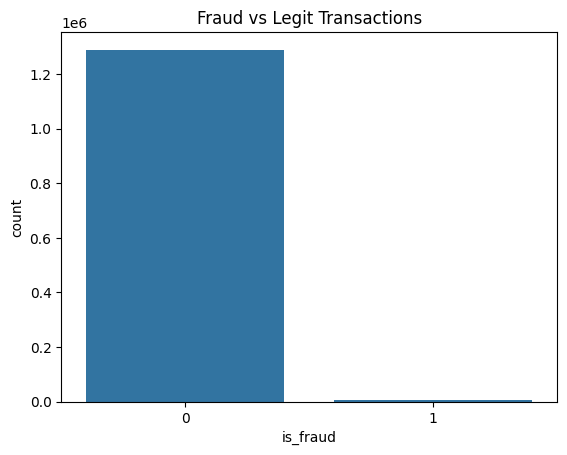

In [ ]:
sns.countplot(x='is_fraud',data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

In [ ]:
df=df.drop(columns=['Unnamed: 0'],errors='ignore')

In [ ]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])
df['hour']=df['trans_date_trans_time'].dt.hour
df['day']=df['trans_date_trans_time'].dt.day
df['month']=df['trans_date_trans_time'].dt.month

In [ ]:
df=df.drop(columns=['trans_date_trans_time'])

In [ ]:
#Dropping the high-cardinality & leakage columns before we perform encoding
cols_to_drop=[
    'first',
    'last',
    'street',
    'trans_num',
    'cc_num']
df=df.drop(columns=cols_to_drop,errors='ignore')

In [ ]:
#Converting DOB to age (better feature than having the raw date)
df['dob']=pd.to_datetime(df['dob'])
df['age']=(pd.to_datetime('today')-df['dob']).dt.days//365
df=df.drop(columns=['dob'])

In [ ]:
#Dropping some additional high-cardinality columns for memory safety
df=df.drop(columns=['merchant','city','job'],errors='ignore')

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['category', 'gender', 'state'], dtype='object')

In [ ]:
#One Hot Encoding
df=pd.get_dummies(df,drop_first=True)

In [ ]:
X=df.drop('is_fraud',axis=1)
y=df['is_fraud']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
lr=LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(X_train_scaled,y_train)

y_pred_lr=lr.predict(X_test_scaled)
y_prob_lr=lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
print(classification_report(y_test,y_pred_lr))
print("ROC-AUC:",roc_auc_score(y_test,y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94    257834
           1       0.04      0.76      0.07      1501

    accuracy                           0.88    259335
   macro avg       0.52      0.82      0.50    259335
weighted avg       0.99      0.88      0.93    259335

ROC-AUC: 0.9152241405941656


In [ ]:
rf=RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
y_prob_rf=rf.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test,y_pred_rf))
print("ROC-AUC:",roc_auc_score(y_test,y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.23      0.89      0.36      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.94      0.68    259335
weighted avg       0.99      0.98      0.99    259335

ROC-AUC: 0.9842653772600963


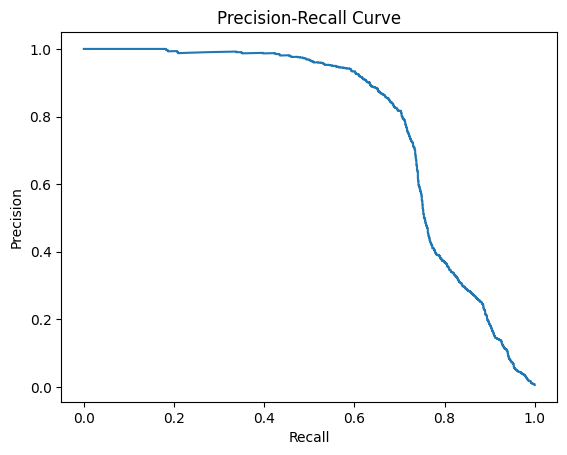

Average Precision Score: 0.7729300127862312


In [ ]:
precision,recall,thresholds=precision_recall_curve(y_test,y_prob_rf)
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
print("Average Precision Score:",average_precision_score(y_test,y_prob_rf))

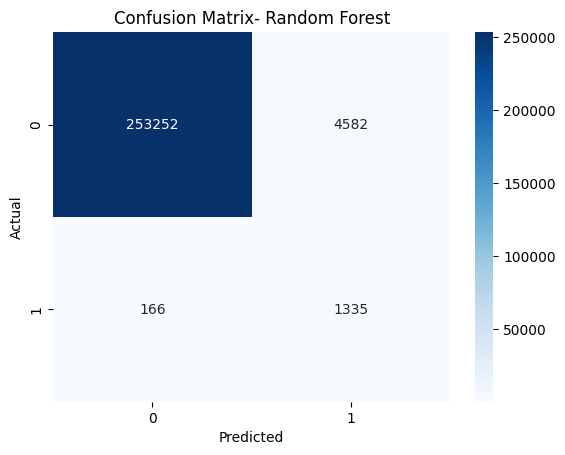

In [ ]:
cm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix- Random Forest")
plt.show()

In [ ]:
custom_threshold=0.3
y_custom=(y_prob_rf>=custom_threshold).astype(int)
print(classification_report(y_test,y_custom))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92    257834
           1       0.04      0.97      0.07      1501

    accuracy                           0.86    259335
   macro avg       0.52      0.92      0.50    259335
weighted avg       0.99      0.86      0.92    259335



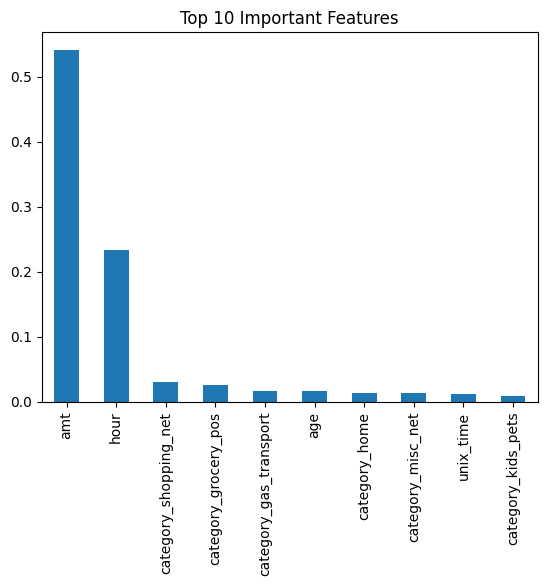

In [ ]:
importances=pd.Series(rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)
importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

# **Business Interpretation:**

The Random Forest model achieved a ROC-AUC score of **0.984** and an Average Precision Score of **0.773**, indicating strong discriminative ability on a highly imbalanced dataset.

At the default threshold (0.5):
* Fraud recall= 89%
* Fraud precision= 23%

Lowering the threshold to **0.3** increased recal to **97%** but significantly reduced precision to **4%**, meaning many legitimate transactions would be flagged as fraud.

This demonstrates the tradeoff between catching more fraud (higher recall) and minimizing false alarms (higher precision). In real-world deployment, the optimal threshold would depend on business cost considerations:

* Cost of missed fraud (false negatives)
* Cost of blocking legitimate customers (false positives)